# Preventing Data Leakage in Simulated TCSPC Data

This notebook investigates how train-test splitting strategies affect the evaluation of machine-learning models trained on simulated TCSPC decay curves.

Synthetic datasets often contain several Poisson-noisy realizations generated from the same underlying physical parameters. If these closely related curves are randomly distributed between the training and test sets, the resulting evaluation may be unrealistically optimistic.

The notebook compares:

* an ordinary random row-level split;
* a group-aware split based on simulation parameter sets;
* a lifetime-interval holdout experiment;
* a noise-robustness experiment.

The purpose is to distinguish performance on familiar parameter regions from robustness to genuinely unfamiliar physical or statistical conditions.

## 1. Scientific motivation

A supervised machine-learning model is normally trained on one subset of a dataset and evaluated on another subset that was not used during training.

For the evaluation to be scientifically meaningful, the test samples should represent genuinely unseen information.

In simulated TCSPC datasets, however, multiple measured curves may be generated from the same expected decay curve. For example, several Poisson-noisy realizations may share exactly the same:

* fluorescence lifetime;
* decay amplitude;
* background level;
* time axis;
* decay model.

Only the random Poisson realization differs between these curves.

Consider three simulated curves generated using the same physical parameters:

- lifetime: 2.5 ns
- amplitude: 10,000 counts
- background: 5 counts per bin

The corresponding measured curves may differ because independent Poisson noise is applied:

| Curve | Parameter set | Random seed |
|---:|---|---:|
| 1 | A | 101 |
| 2 | A | 102 |
| 3 | A | 103 |

An ordinary random train-test split may assign curves 1 and 2 to the training set and curve 3 to the test set.

Although curve 3 was not directly used during training, it originates from the same expected decay curve as curves 1 and 2.

The model is therefore tested on a sample that is statistically new but physically almost identical to samples already present in the training set.

This problem is not classical target leakage because the true lifetime is not directly included among the model input features.

Instead, it is a form of **simulation-group leakage** or **dependence between training and test samples**.

The training and test sets are not sufficiently independent because they contain different noisy realizations of the same underlying simulation parameter set.

A model evaluated under these conditions may achieve a very small test error without demonstrating that it can generalize to:

* unseen lifetime values;
* unseen combinations of lifetime, amplitude, and background;
* lower photon-count conditions;
* stronger background noise;
* different decay models;
* unfamiliar instrument-response functions.

It is therefore important to define what kind of generalization each evaluation experiment is intended to measure.

In this notebook, four generalization concepts are distinguished.

### Interpolation performance

The test data lie within the physical parameter ranges represented during training, but the exact simulation parameter combinations are new.

### Robustness to new noise levels

The physical decay model remains unchanged, but the test curves contain photon counts or background levels not represented during training.

### Robustness to model mismatch

The test curves do not exactly follow the decay model used to generate the training data. For example, a model trained on mono-exponential curves may later be tested on bi-exponential curves.

### Robustness to unfamiliar IRFs

After instrument-response-function convolution is added to the toolkit, a model may be trained using one family of IRFs and evaluated using different IRF
shapes or widths.

The main question throughout this notebook is:

> What exactly is unfamiliar to the model in the test set?

A test set may differ from the training set only through a new Poisson realization, or it may introduce a genuinely new physical or statistical
condition.

These situations support different scientific claims and should therefore be evaluated separately.

In [2]:
from pathlib import Path
from math import comb

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    train_test_split,
)

from tcspc_toolkit.models import monoexponential_decay
from tcspc_toolkit.simulation import sample_photon_counts

## 2. Generation of repeated noise realizations

To demonstrate the difference between row-level and group-aware splitting, this
notebook requires a dataset containing several measured curves for each
underlying physical parameter combination.

For one parameter group, the lifetime, amplitude, background, time axis, and
expected decay curve remain fixed. Multiple measured curves are then generated
by applying independent Poisson sampling to that same expected curve.

The resulting hierarchy is:

```text
simulation parameter group
├── Poisson realization 1
├── Poisson realization 2
├── Poisson realization 3
└── ...
```

Curves belonging to one group are not numerically identical because every Poisson realization is independently sampled. Nevertheless, they share the same underlying expected decay and are therefore more closely related than curves generated from different physical parameter combinations.

### Why we need both identifiers

We will eventually have metadata similar to:

| `curve_id` | `parameter_group` | `realization_id` | `lifetime_ns` |
|---:|---:|---:|---:|
| 0 | 0 | 0 | 1.25 |
| 1 | 0 | 1 | 1.25 |
| 2 | 0 | 2 | 1.25 |
| 3 | 1 | 0 | 2.50 |

Three identifiers will be retained

- `curve_id` uniquely identifies every measured histogram;
- `parameter_group` identifies the shared expected decay;
- `realization_id` identifies the Poisson draw inside that group.

The `parameter_group` variable will later be used to ensure that all realizations of one expected decay are assigned either to the training set or to the test set, but never to both.

In [3]:
n_time_bins = 256
start_time_ns = 0.0
end_time_ns = 12.0

time_ns = np.linspace(
    start_time_ns,
    end_time_ns,
    n_time_bins,
    dtype=np.float64,
)

n_parameter_groups = 500
n_realizations_per_group = 5

lifetime_range_ns = (0.5, 5.0)
amplitude_range = (500.0, 10_000.0)
background_range = (0.0, 10.0)

random_seed = 42
rng = np.random.default_rng(random_seed)

In [4]:
n_curves = n_parameter_groups * n_realizations_per_group

print(f"Number of parameter groups: {n_parameter_groups}")
print(f"Realizations per group: {n_realizations_per_group}")
print(f"Total number of curves: {n_curves}")
print(f"Number of time bins: {n_time_bins}")
print(f"Input-matrix shape: ({n_curves}, {n_time_bins})")

Number of parameter groups: 500
Realizations per group: 5
Total number of curves: 2500
Number of time bins: 256
Input-matrix shape: (2500, 256)


### Sample parameter groups

In [5]:
group_lifetimes_ns = rng.uniform(
    low=lifetime_range_ns[0],
    high=lifetime_range_ns[1],
    size=n_parameter_groups,
)

group_amplitudes = rng.uniform(
    low=amplitude_range[0],
    high=amplitude_range[1],
    size=n_parameter_groups,
)

group_backgrounds = rng.uniform(
    low=background_range[0],
    high=background_range[1],
    size=n_parameter_groups,
)

In [6]:
parameter_table = pd.DataFrame(
    {
        "parameter_group": np.arange(
            n_parameter_groups,
            dtype=np.int64,
        ),
        "lifetime_ns": group_lifetimes_ns,
        "amplitude": group_amplitudes,
        "background": group_backgrounds,
    }
)

parameter_table.head()

,parameter_group,lifetime_ns,amplitude,background
0,0,3.982802,7498.704041,0.620631
1,1,2.474953,8920.827424,4.582620
2,2,4.363691,9250.043374,1.290301
3,3,3.638156,5284.512789,1.523267
4,4,0.923798,5442.613590,6.322828


In [7]:
parameter_table.describe()

,parameter_group,lifetime_ns,amplitude,background
count,500.000000,500.000000,500.000000,500.000000
mean,249.500000,2.730566,5237.406222,5.045747
std,144.481833,1.290476,2817.704575,2.915219
min,0.000000,0.524434,511.714094,0.005187
25%,124.750000,1.561917,2811.523587,2.460615
50%,249.500000,2.754018,5190.300206,4.924648
75%,374.250000,3.862599,7752.092448,7.590803
max,499.000000,4.995971,9988.062016,9.994219


In [8]:
assert np.all(group_lifetimes_ns >= lifetime_range_ns[0])
assert np.all(group_lifetimes_ns < lifetime_range_ns[1])

assert np.all(group_amplitudes >= amplitude_range[0])
assert np.all(group_amplitudes < amplitude_range[1])

assert np.all(group_backgrounds >= background_range[0])
assert np.all(group_backgrounds < background_range[1])

In [9]:
measured_curves = np.empty(
    shape=(n_curves, n_time_bins),
    dtype=np.int64,
)

expected_curves = np.empty(
    shape=(n_parameter_groups, n_time_bins),
    dtype=np.float64,
)

In [10]:
curve_ids = np.arange(n_curves, dtype=np.int64)

parameter_groups = np.empty(
    n_curves,
    dtype=np.int64,
)

realization_ids = np.empty(
    n_curves,
    dtype=np.int64,
)

curve_lifetimes_ns = np.empty(
    n_curves,
    dtype=np.float64,
)

curve_amplitudes = np.empty(
    n_curves,
    dtype=np.float64,
)

curve_backgrounds = np.empty(
    n_curves,
    dtype=np.float64,
)

### Generate the grouped curves

In [11]:
curve_id = 0

for parameter_group in range(n_parameter_groups):
    lifetime_ns = group_lifetimes_ns[parameter_group]
    amplitude = group_amplitudes[parameter_group]
    background = group_backgrounds[parameter_group]

    expected_counts = monoexponential_decay(
        time=time_ns,
        amplitude=amplitude,
        lifetime=lifetime_ns,
        background=background,
    )

    expected_curves[parameter_group] = expected_counts

    for realization_id in range(n_realizations_per_group):
        measured_counts = sample_photon_counts(
            expected_counts=expected_counts,
            rng=rng,
        )

        measured_curves[curve_id] = measured_counts
        parameter_groups[curve_id] = parameter_group
        realization_ids[curve_id] = realization_id
        curve_lifetimes_ns[curve_id] = lifetime_ns
        curve_amplitudes[curve_id] = amplitude
        curve_backgrounds[curve_id] = background

        curve_id += 1

In [12]:
assert curve_id == n_curves
assert measured_curves.shape == (n_curves, n_time_bins)
assert expected_curves.shape == (
    n_parameter_groups,
    n_time_bins,
)

In [13]:
curve_metadata = pd.DataFrame(
    {
        "curve_id": curve_ids,
        "parameter_group": parameter_groups,
        "realization_id": realization_ids,
        "lifetime_ns": curve_lifetimes_ns,
        "amplitude": curve_amplitudes,
        "background": curve_backgrounds,
        "measured_total_counts": measured_curves.sum(axis=1),
    }
)

curve_metadata.head(10)

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,0,0,0,3.982802,7498.704041,0.620631,608338
1,1,0,1,3.982802,7498.704041,0.620631,607223
2,2,0,2,3.982802,7498.704041,0.620631,606840
3,3,0,3,3.982802,7498.704041,0.620631,608589
4,4,0,4,3.982802,7498.704041,0.620631,607563
5,5,1,0,2.474953,8920.827424,4.582620,470429
6,6,1,1,2.474953,8920.827424,4.582620,470395
7,7,1,2,2.474953,8920.827424,4.582620,470939
8,8,1,3,2.474953,8920.827424,4.582620,471519
9,9,1,4,2.474953,8920.827424,4.582620,470882


In [14]:
group_sizes = curve_metadata.groupby(
    "parameter_group"
).size()

assert group_sizes.nunique() == 1
assert group_sizes.iloc[0] == n_realizations_per_group

In [15]:
within_group_parameter_counts = (
    curve_metadata.groupby("parameter_group")[
        ["lifetime_ns", "amplitude", "background"]
    ]
    .nunique()
)

assert np.all(
    within_group_parameter_counts.to_numpy() == 1
)

In [16]:
first_group_indices = np.flatnonzero(
    parameter_groups == 0
)

first_group_curves = measured_curves[
    first_group_indices
]

n_unique_curves_in_first_group = np.unique(
    first_group_curves,
    axis=0,
).shape[0]

print(
    "Unique measured curves in the first group:",
    n_unique_curves_in_first_group,
)

Unique measured curves in the first group: 5


### Visual comparison of repeated realizations

The curves below belong to one simulation parameter group. They therefore share the same lifetime, amplitude, background, and expected decay. Their visible differences arise only from independent Poisson sampling.

This illustrates why the curves are neither exact duplicates nor fully independent physical cases.


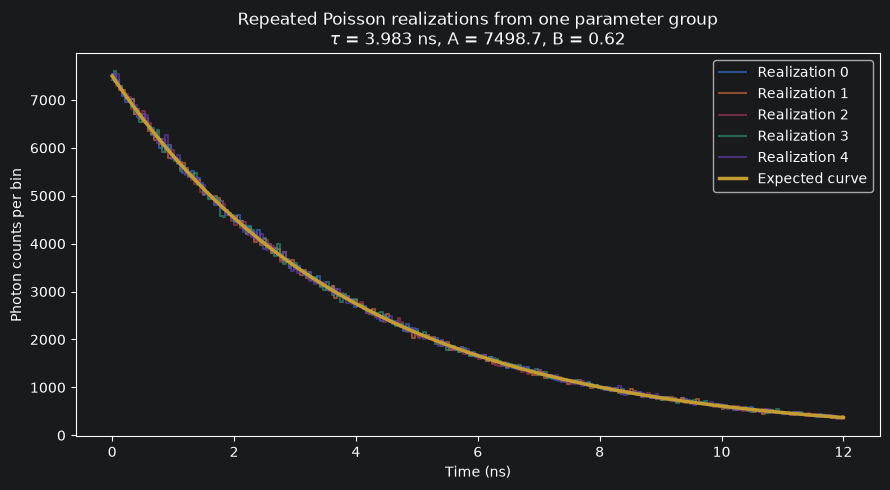

In [17]:
selected_group = 0

selected_indices = np.flatnonzero(
    parameter_groups == selected_group
)

selected_lifetime = group_lifetimes_ns[selected_group]
selected_amplitude = group_amplitudes[selected_group]
selected_background = group_backgrounds[selected_group]

plt.figure(figsize=(9, 5))

for index in selected_indices:
    realization_id = realization_ids[index]

    plt.step(
        time_ns,
        measured_curves[index],
        where="mid",
        alpha=0.65,
        label=f"Realization {realization_id}",
    )

plt.plot(
    time_ns,
    expected_curves[selected_group],
    linewidth=2.5,
    label="Expected curve",
)

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts per bin")
plt.title(
    "Repeated Poisson realizations from one parameter group\n"
    f"$\\tau$ = {selected_lifetime:.3f} ns, "
    f"A = {selected_amplitude:.1f}, "
    f"B = {selected_background:.2f}"
)
plt.legend()
plt.tight_layout()
plt.show()

### Preparation of model inputs

As in the first machine-learning baseline, each measured histogram is normalized by its total photon count:

$$
x_{i,j}^{\mathrm{norm}}
=
\frac{x_{i,j}}{\sum_k x_{i,k}},
$$

where \(i\) indexes the decay curve, \(j\) indexes the time bin, and the sum runs over all time bins \(k\) of curve \(i\).

This removes the overall count scale and makes the initial model input primarily represent the temporal shape of each decay. The unnormalized total photon count is retained separately in the metadata for later noise-dependent evaluation.

Because each curve is normalized using only its own measured counts, this operation does not estimate parameters from the complete dataset and therefore does not transfer population-level information between training and test sets.


In [18]:
curve_totals = measured_curves.sum(
    axis=1,
    keepdims=True,
)

if np.any(curve_totals == 0):
    raise ValueError(
        "At least one simulated curve contains zero total counts."
    )

X = (
    measured_curves.astype(np.float64)
    / curve_totals
)

y = curve_lifetimes_ns.copy()
groups = parameter_groups.copy()

In [19]:
row_sums = X.sum(axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Minimum normalized row sum:", row_sums.min())
print("Maximum normalized row sum:", row_sums.max())

assert np.allclose(row_sums, 1.0)

X shape: (2500, 256)
y shape: (2500,)
groups shape: (2500,)
Minimum normalized row sum: 0.9999999999999996
Maximum normalized row sum: 1.0000000000000004


## 3. Naive row-wise random split

A conventional machine-learning workflow often treats every row of the feature matrix as an independent observation and randomly assigns rows to training and
test subsets.

For the present dataset, such a split operates at the level of individual Poisson realizations:

```text
curve 0  ──► training or test
curve 1  ──► training or test
curve 2  ──► training or test
```

The splitting algorithm does not know that several rows may share the same lifetime, amplitude, background, and expected decay curve. It therefore does not prevent different realizations from one parameter group from appearing in both subsets.

This section intentionally applies that naive row-wise strategy. It provides a reference evaluation protocol that will later be compared with a group-aware split.

The split is performed using row indices. Retaining the indices makes it possible to apply exactly the same assignment to the feature matrix, target array, group labels, and metadata table.

The phrase **naive** does not mean that `train_test_split()` is generally a bad function. It means that row-wise splitting is naive **for this particular hierarchical dataset** because the rows are not independent physical cases.

In [20]:
random_test_size = 0.20
split_random_state = 42

all_indices = np.arange(
    X.shape[0],
    dtype=np.int64,
)

(
    random_train_indices,
    random_test_indices,
) = train_test_split(
    all_indices,
    test_size=random_test_size,
    random_state=split_random_state,
    shuffle=True,
)

In [21]:
print(
    "Number of random training indices:",
    random_train_indices.size,
)
print(
    "Number of random test indices:",
    random_test_indices.size,
)
print(
    "Total number of assigned indices:",
    random_train_indices.size
    + random_test_indices.size,
)

Number of random training indices: 2000
Number of random test indices: 500
Total number of assigned indices: 2500


In [22]:
assert random_train_indices.size == 2000
assert random_test_indices.size == 500

assert np.intersect1d(
    random_train_indices,
    random_test_indices,
).size == 0

combined_random_indices = np.concatenate(
    [
        random_train_indices,
        random_test_indices,
    ]
)

assert np.array_equal(
    np.sort(combined_random_indices),
    all_indices,
)

In [23]:
X_train_random = X[random_train_indices]
X_test_random = X[random_test_indices]

y_train_random = y[random_train_indices]
y_test_random = y[random_test_indices]

groups_train_random = groups[random_train_indices]
groups_test_random = groups[random_test_indices]

In [24]:
metadata_train_random = (
    curve_metadata
    .iloc[random_train_indices]
    .reset_index(drop=True)
)

metadata_test_random = (
    curve_metadata
    .iloc[random_test_indices]
    .reset_index(drop=True)
)

In [25]:
print("Random row-level split")
print("----------------------")
print("X_train shape:", X_train_random.shape)
print("X_test shape: ", X_test_random.shape)
print("y_train shape:", y_train_random.shape)
print("y_test shape: ", y_test_random.shape)
print(
    "Training metadata shape:",
    metadata_train_random.shape,
)
print(
    "Test metadata shape:    ",
    metadata_test_random.shape,
)

Random row-level split
----------------------
X_train shape: (2000, 256)
X_test shape:  (500, 256)
y_train shape: (2000,)
y_test shape:  (500,)
Training metadata shape: (2000, 7)
Test metadata shape:     (500, 7)


In [26]:
assert X_train_random.shape == (
    random_train_indices.size,
    n_time_bins,
)

assert X_test_random.shape == (
    random_test_indices.size,
    n_time_bins,
)

assert y_train_random.shape == (
    random_train_indices.size,
)

assert y_test_random.shape == (
    random_test_indices.size,
)

assert groups_train_random.shape == y_train_random.shape
assert groups_test_random.shape == y_test_random.shape

assert len(metadata_train_random) == X_train_random.shape[0]
assert len(metadata_test_random) == X_test_random.shape[0]

assert (
    X_train_random.shape[0]
    + X_test_random.shape[0]
    == n_curves
)

In [27]:
assert np.array_equal(
    metadata_train_random["curve_id"].to_numpy(),
    curve_ids[random_train_indices],
)

assert np.array_equal(
    metadata_test_random["curve_id"].to_numpy(),
    curve_ids[random_test_indices],
)

assert np.allclose(
    metadata_train_random["lifetime_ns"].to_numpy(),
    y_train_random,
)

assert np.allclose(
    metadata_test_random["lifetime_ns"].to_numpy(),
    y_test_random,
)

assert np.array_equal(
    metadata_train_random[
        "parameter_group"
    ].to_numpy(),
    groups_train_random,
)

assert np.array_equal(
    metadata_test_random[
        "parameter_group"
    ].to_numpy(),
    groups_test_random,
)

In [28]:
metadata_train_random.head()

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,2055,411,0,3.425563,8828.752574,9.758975,629889
1,1961,392,1,3.147161,2814.169081,1.175044,186123
2,1864,372,4,2.138864,9802.634020,4.049941,449726
3,2326,465,1,3.648992,5079.292216,6.728534,384421
4,461,92,1,2.507703,3421.583188,2.893201,183871


In [29]:
metadata_test_random.head()

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,1447,289,2,0.957524,6206.972229,5.679342,131035
1,1114,222,4,3.482889,840.506138,8.945115,62958
2,1064,212,4,1.398990,8239.065210,5.612231,250988
3,2287,457,2,2.563523,5417.784452,4.378416,295417
4,1537,307,2,3.378035,2142.967396,6.689477,152135


### Target distributions under the random split

Because rows are assigned randomly, the training and test subsets are expected to contain similar lifetime distributions. Similar target distributions are useful for measuring interpolation within the simulated lifetime range.

However, distributional similarity alone does not guarantee independence. Training and test curves may have similar lifetime distributions either because they contain different physical parameter combinations or because they contain different Poisson realizations of the same combinations.

In [30]:
random_target_summary = pd.DataFrame(
    {
        "training": pd.Series(y_train_random).describe(),
        "test": pd.Series(y_test_random).describe(),
    }
)

random_target_summary

,training,test
count,2000.000000,500.000000
mean,2.740038,2.692678
std,1.282975,1.315618
min,0.524434,0.524434
25%,1.584368,1.397223
50%,2.754701,2.708181
75%,3.868736,3.832408
max,4.995971,4.995971


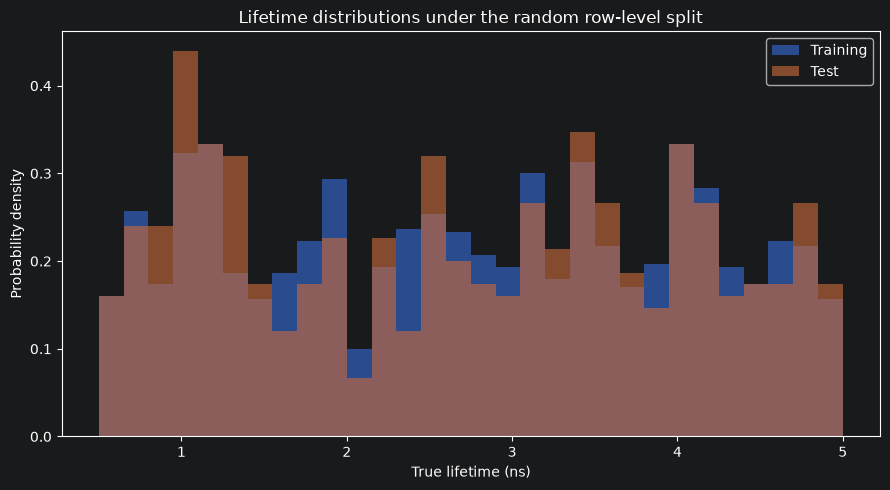

In [31]:
lifetime_bin_edges = np.linspace(
    lifetime_range_ns[0],
    lifetime_range_ns[1],
    31,
)

plt.figure(figsize=(9, 5))

plt.hist(
    y_train_random,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Training",
)

plt.hist(
    y_test_random,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Test",
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Probability density")
plt.title(
    "Lifetime distributions under the random row-level split"
)
plt.legend()
plt.tight_layout()
plt.show()

### Photon-count distributions under the random split

The total number of measured photons influences the magnitude of relative Poisson fluctuations. It is therefore useful to verify whether the random split creates comparable photon-count distributions in the training and test sets.

At this stage, the purpose is descriptive. A dedicated experiment with deliberately separated photon-count regimes will be performed later to evaluate robustness to new noise conditions.

In [32]:
train_total_counts_random = (
    metadata_train_random[
        "measured_total_counts"
    ].to_numpy()
)

test_total_counts_random = (
    metadata_test_random[
        "measured_total_counts"
    ].to_numpy()
)

In [33]:
random_count_summary = pd.DataFrame(
    {
        "training": pd.Series(
            train_total_counts_random
        ).describe(),
        "test": pd.Series(
            test_total_counts_random
        ).describe(),
    }
)

random_count_summary

,training,test
count,2000.000000,500.000000
mean,290704.579000,298243.190000
std,209377.580315,223476.151279
min,12448.000000,15169.000000
25%,124598.000000,124628.750000
50%,233945.000000,219912.000000
75%,424766.250000,453437.000000
max,933951.000000,931607.000000


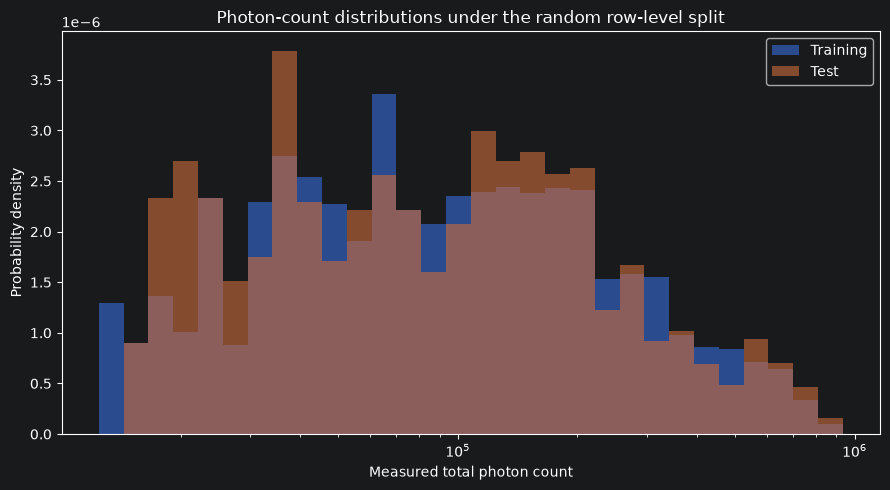

In [34]:
positive_total_counts = curve_metadata.loc[
    curve_metadata["measured_total_counts"] > 0,
    "measured_total_counts",
].to_numpy()

count_bin_edges = np.geomspace(
    positive_total_counts.min(),
    positive_total_counts.max(),
    31,
)

plt.figure(figsize=(9, 5))

plt.hist(
    train_total_counts_random,
    bins=count_bin_edges,
    density=True,
    alpha=0.6,
    label="Training",
)

plt.hist(
    test_total_counts_random,
    bins=count_bin_edges,
    density=True,
    alpha=0.6,
    label="Test",
)

plt.xscale("log")
plt.xlabel("Measured total photon count")
plt.ylabel("Probability density")
plt.title(
    "Photon-count distributions under the random row-level split"
)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
n_train_groups_random = np.unique(
    groups_train_random
).size

n_test_groups_random = np.unique(
    groups_test_random
).size

print(
    "Unique parameter groups represented in training:",
    n_train_groups_random,
)
print(
    "Unique parameter groups represented in test:",
    n_test_groups_random,
)
print(
    "Total parameter groups in the dataset:",
    n_parameter_groups,
)

Unique parameter groups represented in training: 500
Unique parameter groups represented in test: 329
Total parameter groups in the dataset: 500


### Interpretation of the naive split

The random row-level procedure creates two disjoint sets of measured curves:

* no individual histogram appears in both subsets;
* all curves are assigned exactly once;
* the training and test subsets have similar lifetime distributions;
* the training and test subsets have similar photon-count distributions.

These properties make the split look statistically reasonable when each row is treated as an independent observation.

However, row-level disjointness is not equivalent to parameter-group disjointness. Because the splitting algorithm ignored `parameter_group`, different Poisson realizations of the same expected decay may occur in both subsets.

The random split therefore answers the relatively limited question:

> How accurately can the model predict randomly withheld Poisson realizations
> drawn from the same overall simulation campaign?

It does not necessarily answer the stronger question:

> How accurately can the model predict curves generated from unfamiliar
> physical parameter combinations?

The next section constructs a group-aware split in which all realizations from one parameter group are kept together.

## 4. Parameter-group split

The naive split treated every measured histogram as an independent row. A group-aware split instead treats the underlying simulation parameter set as the indivisible observation.

All Poisson realizations generated from one expected decay must be assigned to the same subset:

```text
parameter group
├── realization 0
├── realization 1
├── realization 2
├── realization 3
└── realization 4
        ↓
training or test, but not both
```

This prevents the model from being trained on one noisy realization of an expected decay and tested on another realization of that same decay. The split will be created using `GroupShuffleSplit`. The feature matrix and target values are still divided at the curve level, but the group labels constrain which curves may be separated.

The key distinction is:

```text
Naive split:
individual rows are shuffled independently

Group-aware split:
groups are shuffled, and rows follow their groups
```

In [36]:
group_test_size = 0.20
group_split_random_state = 42

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=group_test_size,
    random_state=group_split_random_state,
)

(
    grouped_train_indices,
    grouped_test_indices,
) = next(
    group_splitter.split(
        X,
        y,
        groups=groups,
    )
)

In [37]:
print(
    "Number of grouped training indices:",
    grouped_train_indices.size,
)
print(
    "Number of grouped test indices:",
    grouped_test_indices.size,
)
print(
    "Total number of assigned indices:",
    grouped_train_indices.size
    + grouped_test_indices.size,
)

Number of grouped training indices: 2000
Number of grouped test indices: 500
Total number of assigned indices: 2500


In [38]:
assert (
    grouped_train_indices.size
    + grouped_test_indices.size
    == n_curves
)

assert np.intersect1d(
    grouped_train_indices,
    grouped_test_indices,
).size == 0

combined_grouped_indices = np.concatenate(
    [
        grouped_train_indices,
        grouped_test_indices,
    ]
)

assert np.array_equal(
    np.sort(combined_grouped_indices),
    all_indices,
)

In [39]:
X_train_grouped = X[grouped_train_indices]
X_test_grouped = X[grouped_test_indices]

y_train_grouped = y[grouped_train_indices]
y_test_grouped = y[grouped_test_indices]

groups_train_grouped = groups[grouped_train_indices]
groups_test_grouped = groups[grouped_test_indices]

In [40]:
metadata_train_grouped = (
    curve_metadata
    .iloc[grouped_train_indices]
    .reset_index(drop=True)
)

metadata_test_grouped = (
    curve_metadata
    .iloc[grouped_test_indices]
    .reset_index(drop=True)
)

In [41]:
print("Group-aware split")
print("-----------------")
print("X_train shape:", X_train_grouped.shape)
print("X_test shape: ", X_test_grouped.shape)
print("y_train shape:", y_train_grouped.shape)
print("y_test shape: ", y_test_grouped.shape)
print(
    "Training metadata shape:",
    metadata_train_grouped.shape,
)
print(
    "Test metadata shape:    ",
    metadata_test_grouped.shape,
)

Group-aware split
-----------------
X_train shape: (2000, 256)
X_test shape:  (500, 256)
y_train shape: (2000,)
y_test shape:  (500,)
Training metadata shape: (2000, 7)
Test metadata shape:     (500, 7)


In [42]:
assert X_train_grouped.shape == (
    grouped_train_indices.size,
    n_time_bins,
)

assert X_test_grouped.shape == (
    grouped_test_indices.size,
    n_time_bins,
)

assert y_train_grouped.shape == (
    grouped_train_indices.size,
)

assert y_test_grouped.shape == (
    grouped_test_indices.size,
)

assert (
    groups_train_grouped.shape
    == y_train_grouped.shape
)

assert (
    groups_test_grouped.shape
    == y_test_grouped.shape
)

assert (
    len(metadata_train_grouped)
    == X_train_grouped.shape[0]
)

assert (
    len(metadata_test_grouped)
    == X_test_grouped.shape[0]
)

In [43]:
assert np.array_equal(
    metadata_train_grouped[
        "curve_id"
    ].to_numpy(),
    curve_ids[grouped_train_indices],
)

assert np.array_equal(
    metadata_test_grouped[
        "curve_id"
    ].to_numpy(),
    curve_ids[grouped_test_indices],
)

assert np.allclose(
    metadata_train_grouped[
        "lifetime_ns"
    ].to_numpy(),
    y_train_grouped,
)

assert np.allclose(
    metadata_test_grouped[
        "lifetime_ns"
    ].to_numpy(),
    y_test_grouped,
)

assert np.array_equal(
    metadata_train_grouped[
        "parameter_group"
    ].to_numpy(),
    groups_train_grouped,
)

assert np.array_equal(
    metadata_test_grouped[
        "parameter_group"
    ].to_numpy(),
    groups_test_grouped,
)

In [44]:
unique_train_groups_grouped = np.unique(
    groups_train_grouped
)

unique_test_groups_grouped = np.unique(
    groups_test_grouped
)

n_train_groups_grouped = (
    unique_train_groups_grouped.size
)

n_test_groups_grouped = (
    unique_test_groups_grouped.size
)

print(
    "Unique parameter groups represented in training:",
    n_train_groups_grouped,
)
print(
    "Unique parameter groups represented in test:",
    n_test_groups_grouped,
)
print(
    "Total represented groups:",
    n_train_groups_grouped
    + n_test_groups_grouped,
)

Unique parameter groups represented in training: 400
Unique parameter groups represented in test: 100
Total represented groups: 500


In [45]:
assert n_train_groups_grouped == 400
assert n_test_groups_grouped == 100

assert (
    n_train_groups_grouped
    + n_test_groups_grouped
    == n_parameter_groups
)

In [46]:
train_group_sizes_grouped = (
    metadata_train_grouped
    .groupby("parameter_group")
    .size()
)

test_group_sizes_grouped = (
    metadata_test_grouped
    .groupby("parameter_group")
    .size()
)

print(
    "Unique training-group sizes:",
    train_group_sizes_grouped.unique(),
)
print(
    "Unique test-group sizes:",
    test_group_sizes_grouped.unique(),
)

Unique training-group sizes: [5]
Unique test-group sizes: [5]


In [47]:
assert np.all(
    train_group_sizes_grouped.to_numpy()
    == n_realizations_per_group
)

assert np.all(
    test_group_sizes_grouped.to_numpy()
    == n_realizations_per_group
)

In [48]:
metadata_train_grouped.sort_values(
    [
        "parameter_group",
        "realization_id",
    ]
).head(10)

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,5,1,0,2.474953,8920.827424,4.582620,470429
1,6,1,1,2.474953,8920.827424,4.582620,470395
2,7,1,2,2.474953,8920.827424,4.582620,470939
3,8,1,3,2.474953,8920.827424,4.582620,471519
4,9,1,4,2.474953,8920.827424,4.582620,470882
5,15,3,0,3.638156,5284.512789,1.523267,396605
6,16,3,1,3.638156,5284.512789,1.523267,396686
7,17,3,2,3.638156,5284.512789,1.523267,396208
8,18,3,3,3.638156,5284.512789,1.523267,396708
9,19,3,4,3.638156,5284.512789,1.523267,395858


In [49]:
metadata_test_grouped.sort_values(
    [
        "parameter_group",
        "realization_id",
    ]
).head(10)

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,0,0,0,3.982802,7498.704041,0.620631,608338
1,1,0,1,3.982802,7498.704041,0.620631,607223
2,2,0,2,3.982802,7498.704041,0.620631,606840
3,3,0,3,3.982802,7498.704041,0.620631,608589
4,4,0,4,3.982802,7498.704041,0.620631,607563
5,10,2,0,4.363691,9250.043374,1.290301,806380
6,11,2,1,4.363691,9250.043374,1.290301,809886
7,12,2,2,4.363691,9250.043374,1.290301,808204
8,13,2,3,4.363691,9250.043374,1.290301,807797
9,14,2,4,4.363691,9250.043374,1.290301,807015


### Target distributions under the grouped split

`GroupShuffleSplit` separates parameter groups but does not explicitly balance the target lifetime distribution.

Because the group lifetimes were independently sampled from the same continuous uniform distribution, the training and test lifetime distributions should usually remain broadly similar. Small differences may nevertheless occur because only 100 parameter groups are assigned to the test set.

The grouped test set therefore evaluates interpolation to new parameter combinations within approximately the same overall lifetime range.

In [50]:
grouped_target_summary = pd.DataFrame(
    {
        "training": pd.Series(
            y_train_grouped
        ).describe(),
        "test": pd.Series(
            y_test_grouped
        ).describe(),
    }
)

grouped_target_summary

,training,test
count,2000.000000,500.000000
mean,2.737453,2.703019
std,1.271294,1.360596
min,0.524434,0.555362
25%,1.581648,1.508338
50%,2.738147,2.774426
75%,3.811621,3.976566
max,4.986656,4.995971


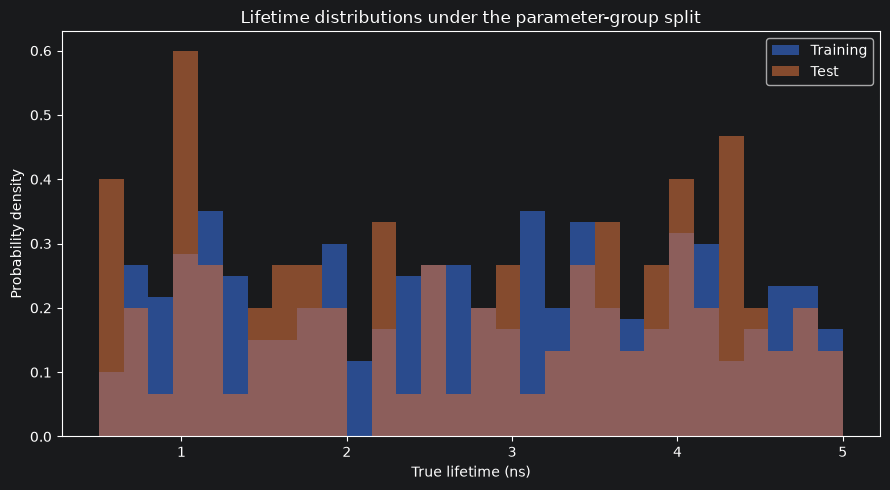

In [51]:
plt.figure(figsize=(9, 5))

plt.hist(
    y_train_grouped,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Training",
)

plt.hist(
    y_test_grouped,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Test",
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Probability density")
plt.title(
    "Lifetime distributions under the parameter-group split"
)
plt.legend()
plt.tight_layout()
plt.show()

### Distribution of unique group lifetimes

Every lifetime occurs once per parameter group but is repeated for each Poisson realization in the curve-level target arrays. To display the physical parameter distribution directly, one lifetime can be retained for each unique group.

In [52]:
train_group_lifetimes = (
    metadata_train_grouped
    .groupby("parameter_group")["lifetime_ns"]
    .first()
    .to_numpy()
)

test_group_lifetimes = (
    metadata_test_grouped
    .groupby("parameter_group")["lifetime_ns"]
    .first()
    .to_numpy()
)

In [53]:
assert train_group_lifetimes.size == 400
assert test_group_lifetimes.size == 100

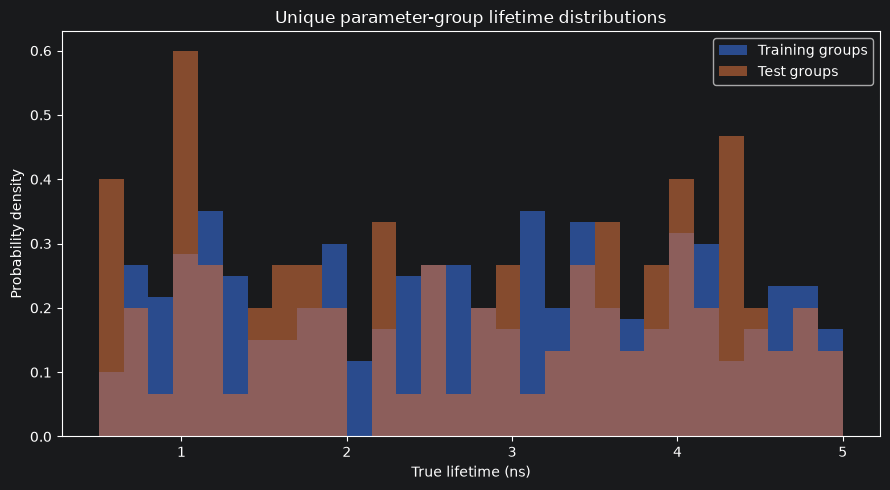

In [54]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_group_lifetimes,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Training groups",
)

plt.hist(
    test_group_lifetimes,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Test groups",
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Probability density")
plt.title(
    "Unique parameter-group lifetime distributions"
)
plt.legend()
plt.tight_layout()
plt.show()

### Photon-count distributions under the grouped split

Although all realizations within one parameter group share the same expected curve, their measured total counts vary because of Poisson sampling.

The grouped split separates complete physical parameter sets. Consequently, differences in photon-count distributions can arise from both:

* different amplitudes, backgrounds, and lifetimes assigned to the selected
  groups;
* stochastic variation among Poisson realizations within those groups.

The present grouped experiment does not deliberately separate photon-count regimes. It only prevents shared parameter combinations across the split.

In [55]:
train_total_counts_grouped = (
    metadata_train_grouped[
        "measured_total_counts"
    ].to_numpy()
)

test_total_counts_grouped = (
    metadata_test_grouped[
        "measured_total_counts"
    ].to_numpy()
)

In [56]:
grouped_count_summary = pd.DataFrame(
    {
        "training": pd.Series(
            train_total_counts_grouped
        ).describe(),
        "test": pd.Series(
            test_total_counts_grouped
        ).describe(),
    }
)

grouped_count_summary

,training,test
count,2000.000000,500.000000
mean,287097.525000,312671.406000
std,211064.848227,215919.006998
min,12448.000000,28751.000000
25%,118293.750000,145887.250000
50%,220272.000000,263115.500000
75%,424373.500000,446179.250000
max,933951.000000,809886.000000


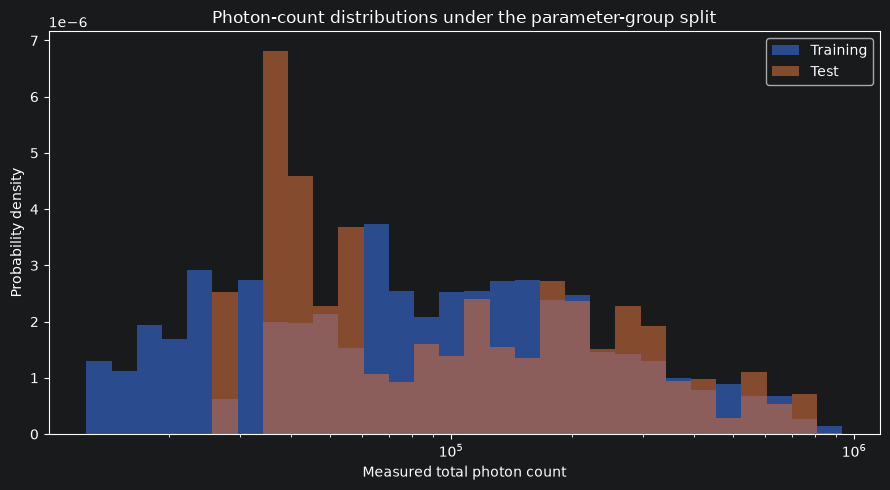

In [57]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_total_counts_grouped,
    bins=count_bin_edges,
    density=True,
    alpha=0.6,
    label="Training",
)

plt.hist(
    test_total_counts_grouped,
    bins=count_bin_edges,
    density=True,
    alpha=0.6,
    label="Test",
)

plt.xscale("log")
plt.xlabel("Measured total photon count")
plt.ylabel("Probability density")
plt.title(
    "Photon-count distributions under the parameter-group split"
)
plt.legend()
plt.tight_layout()
plt.show()

### Comparison of subset sizes

The random and grouped protocols contain the same number of training and test curves. Therefore, later differences in model performance cannot be attributed simply to unequal sample counts.

The protocols differ in which relationships between observations are allowed across the split.

In [58]:
split_size_comparison = pd.DataFrame(
    {
        "protocol": [
            "Random row-level",
            "Parameter-group",
        ],
        "training_curves": [
            X_train_random.shape[0],
            X_train_grouped.shape[0],
        ],
        "test_curves": [
            X_test_random.shape[0],
            X_test_grouped.shape[0],
        ],
        "training_unique_groups": [
            n_train_groups_random,
            n_train_groups_grouped,
        ],
        "test_unique_groups": [
            n_test_groups_random,
            n_test_groups_grouped,
        ],
    }
)

split_size_comparison

,protocol,training_curves,test_curves,training_unique_groups,test_unique_groups
0,Random row-level,2000,500,500,329
1,Parameter-group,2000,500,400,100


### Interpretation of the parameter-group split

The group-aware procedure preserves the complete simulation hierarchy:

* every measured curve is assigned exactly once;
* every parameter group retains all of its Poisson realizations;
* approximately 80% of parameter groups are used for training;
* approximately 20% of parameter groups are reserved for testing;
* the training and test subsets remain within the same broad simulated
  lifetime and photon-count ranges.

Unlike the naive row-level split, this procedure does not allow an expected decay curve to contribute noisy realizations to both subsets.

The grouped protocol therefore asks a stronger question:

> How accurately can the model predict Poisson-sampled curves generated from
> parameter combinations that were not represented during training?

This remains an interpolation experiment because the held-out lifetimes, amplitudes, and backgrounds are sampled from the same overall parameter ranges as the training groups. It is not yet a test of extrapolation, unfamiliar noise regimes, model mismatch, or unfamiliar IRFs.

The next section verifies the defining property of the two protocols by measuring parameter-group overlap between their training and test subsets.

## 5. Verification of parameter-group overlap

A train–test split can be disjoint at the row level while still containing closely related observations in both subsets.

For the present dataset, two rows are related when they have the same `parameter_group`. Such curves share the same:

* lifetime;
* amplitude;
* background;
* time axis;
* expected mono-exponential decay.

They differ only through independent Poisson sampling.

This section converts the group-label arrays into sets and measures their intersection. The intersection contains parameter groups represented in both the training and test subsets.

For the naive row-level split, a non-empty intersection is expected because individual realizations were assigned independently. For the group-aware split, the intersection must be empty.

In [59]:
random_train_group_set = set(
    groups_train_random.tolist()
)

random_test_group_set = set(
    groups_test_random.tolist()
)

In [60]:
overlapping_groups_random = (
    random_train_group_set
    & random_test_group_set
)

In [61]:
n_overlapping_groups_random = len(
    overlapping_groups_random
)

print(
    "Random split training groups:",
    len(random_train_group_set),
)
print(
    "Random split test groups:",
    len(random_test_group_set),
)
print(
    "Groups represented in both subsets:",
    n_overlapping_groups_random,
)

Random split training groups: 500
Random split test groups: 329
Groups represented in both subsets: 329


In [62]:
random_test_group_overlap_fraction = (
    n_overlapping_groups_random
    / len(random_test_group_set)
)

random_train_group_overlap_fraction = (
    n_overlapping_groups_random
    / len(random_train_group_set)
)

print(
    "Fraction of test groups also present in training:",
    f"{random_test_group_overlap_fraction:.3f}",
)

print(
    "Fraction of training groups also present in test:",
    f"{random_train_group_overlap_fraction:.3f}",
)

Fraction of test groups also present in training: 1.000
Fraction of training groups also present in test: 0.658


In [63]:
random_train_only_groups = (
    random_train_group_set
    - random_test_group_set
)

random_test_only_groups = (
    random_test_group_set
    - random_train_group_set
)

print(
    "Groups found only in random training:",
    len(random_train_only_groups),
)

print(
    "Groups found only in random test:",
    len(random_test_only_groups),
)

print(
    "Groups shared across random training and test:",
    len(overlapping_groups_random),
)

Groups found only in random training: 171
Groups found only in random test: 0
Groups shared across random training and test: 329


In [64]:
assert random_train_only_groups.isdisjoint(
    random_test_only_groups
)

assert random_train_only_groups.isdisjoint(
    overlapping_groups_random
)

assert random_test_only_groups.isdisjoint(
    overlapping_groups_random
)

In [65]:
all_random_represented_groups = (
    random_train_only_groups
    | random_test_only_groups
    | overlapping_groups_random
)

all_parameter_group_set = set(
    np.arange(
        n_parameter_groups,
        dtype=np.int64,
    ).tolist()
)

assert (
    all_random_represented_groups
    == all_parameter_group_set
)

In [66]:
sorted_overlapping_groups_random = sorted(
    overlapping_groups_random
)

print(
    "First ten overlapping groups:",
    sorted_overlapping_groups_random[:10],
)

First ten overlapping groups: [5, 8, 9, 10, 11, 13, 14, 15, 16, 18]


In [67]:
example_overlapping_group = (
    sorted_overlapping_groups_random[0]
)

example_random_train_rows = (
    metadata_train_random.loc[
        metadata_train_random[
            "parameter_group"
        ] == example_overlapping_group
    ]
    .sort_values("realization_id")
)

example_random_test_rows = (
    metadata_test_random.loc[
        metadata_test_random[
            "parameter_group"
        ] == example_overlapping_group
    ]
    .sort_values("realization_id")
)

example_random_train_rows
example_random_test_rows

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
399,25,5,0,4.890301,8098.768902,3.929274,775803
286,29,5,4,4.890301,8098.768902,3.929274,775498


In [68]:
example_random_combined_rows = pd.concat(
    [
        example_random_train_rows,
        example_random_test_rows,
    ],
    ignore_index=True,
)

example_random_parameter_counts = (
    example_random_combined_rows[
        [
            "lifetime_ns",
            "amplitude",
            "background",
        ]
    ]
    .nunique()
)

example_random_parameter_counts

lifetime_ns    1
amplitude      1
background     1
dtype: int64

In [69]:
assert np.all(
    example_random_parameter_counts.to_numpy()
    == 1
)

In [70]:
random_train_realizations_per_group = (
    metadata_train_random
    .groupby("parameter_group")
    .size()
    .rename("training_realizations")
)

random_test_realizations_per_group = (
    metadata_test_random
    .groupby("parameter_group")
    .size()
    .rename("test_realizations")
)

random_group_assignment_table = pd.concat(
    [
        random_train_realizations_per_group,
        random_test_realizations_per_group,
    ],
    axis=1,
).fillna(0)

random_group_assignment_table = (
    random_group_assignment_table.astype(np.int64)
)

random_group_assignment_table.head(10)

,training_realizations,test_realizations
parameter_group,,
0,5,0
1,5,0
2,5,0
3,5,0
4,5,0
5,3,2
6,5,0
7,5,0
8,3,2


In [71]:
random_group_assignment_table[
    "total_realizations"
] = (
    random_group_assignment_table[
        "training_realizations"
    ]
    + random_group_assignment_table[
        "test_realizations"
    ]
)

assert np.all(
    random_group_assignment_table[
        "total_realizations"
    ].to_numpy()
    == n_realizations_per_group
)

In [72]:
random_assignment_patterns = (
    random_group_assignment_table
    .groupby(
        [
            "training_realizations",
            "test_realizations",
        ]
    )
    .size()
    .rename("number_of_groups")
    .reset_index()
    .sort_values(
        [
            "test_realizations",
            "training_realizations",
        ]
    )
)

random_assignment_patterns

,training_realizations,test_realizations,number_of_groups
4,5,0,171
3,4,1,193
2,3,2,104
1,2,3,29
0,1,4,3


### Distribution of realization assignments

The naive split can divide the five realizations of one parameter group in several ways. Examining these assignment patterns shows how frequently a test group is represented by one or more closely related training curves.

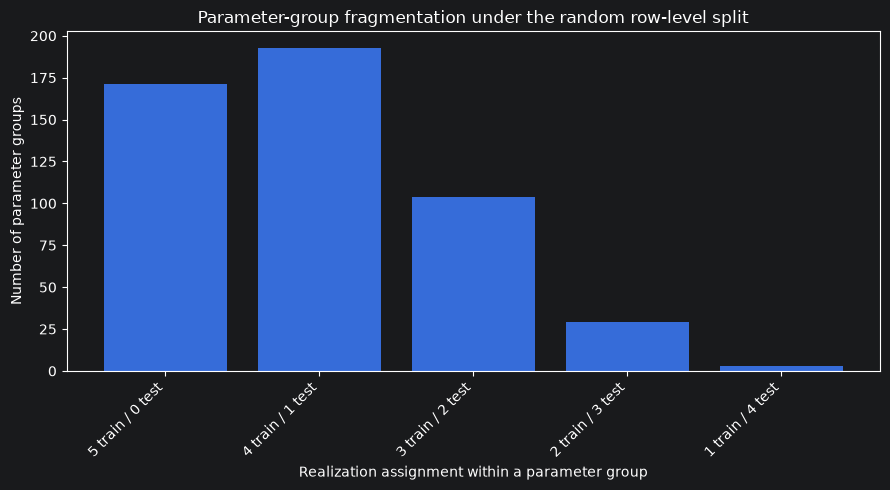

In [73]:
random_assignment_patterns[
    "assignment_label"
] = (
    random_assignment_patterns[
        "training_realizations"
    ].astype(str)
    + " train / "
    + random_assignment_patterns[
        "test_realizations"
    ].astype(str)
    + " test"
)

plt.figure(figsize=(9, 5))

plt.bar(
    random_assignment_patterns[
        "assignment_label"
    ],
    random_assignment_patterns[
        "number_of_groups"
    ],
)

plt.xlabel("Realization assignment within a parameter group")
plt.ylabel("Number of parameter groups")
plt.title(
    "Parameter-group fragmentation under the random row-level split"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

A bar such as:

```
4 train / 1 test
```

means that for those groups, the model receives four Poisson realizations during training and is evaluated on the fifth realization. That is a much easier test than predicting an entirely unfamiliar parameter combination.

## Now we repeat the overlap calculation for the group-aware protocol

In [74]:
grouped_train_group_set = set(
    groups_train_grouped.tolist()
)

grouped_test_group_set = set(
    groups_test_grouped.tolist()
)

In [75]:
assert (
    len(grouped_train_group_set)
    == n_train_groups_grouped
)

assert (
    len(grouped_test_group_set)
    == n_test_groups_grouped
)

In [76]:
overlapping_groups_grouped = (
    grouped_train_group_set
    & grouped_test_group_set
)

n_overlapping_groups_grouped = len(
    overlapping_groups_grouped
)

print(
    "Grouped split training groups:",
    len(grouped_train_group_set),
)
print(
    "Grouped split test groups:",
    len(grouped_test_group_set),
)
print(
    "Groups represented in both subsets:",
    n_overlapping_groups_grouped,
)

Grouped split training groups: 400
Grouped split test groups: 100
Groups represented in both subsets: 0


In [77]:
assert n_overlapping_groups_grouped == 0

assert grouped_train_group_set.isdisjoint(
    grouped_test_group_set
)

In [78]:
all_grouped_represented_groups = (
    grouped_train_group_set
    | grouped_test_group_set
)

assert (
    all_grouped_represented_groups
    == all_parameter_group_set
)

assert (
    len(grouped_train_group_set)
    + len(grouped_test_group_set)
    == n_parameter_groups
)

In [79]:
assert np.all(
    metadata_train_grouped
    .groupby("parameter_group")
    .size()
    .to_numpy()
    == n_realizations_per_group
)

assert np.all(
    metadata_test_grouped
    .groupby("parameter_group")
    .size()
    .to_numpy()
    == n_realizations_per_group
)

### Direct comparison of group overlap

The two splitting protocols contain equal numbers of curves but differ strongly in group independence. The table below compares the number and fraction of shared parameter groups.

In [80]:
grouped_test_group_overlap_fraction = (
    n_overlapping_groups_grouped
    / len(grouped_test_group_set)
)

overlap_comparison = pd.DataFrame(
    {
        "protocol": [
            "Random row-level",
            "Parameter-group",
        ],
        "training_unique_groups": [
            len(random_train_group_set),
            len(grouped_train_group_set),
        ],
        "test_unique_groups": [
            len(random_test_group_set),
            len(grouped_test_group_set),
        ],
        "overlapping_groups": [
            n_overlapping_groups_random,
            n_overlapping_groups_grouped,
        ],
        "test_groups_also_in_training_fraction": [
            random_test_group_overlap_fraction,
            grouped_test_group_overlap_fraction,
        ],
    }
)

overlap_comparison

,protocol,training_unique_groups,test_unique_groups,overlapping_groups,test_groups_also_in_training_fraction
0,Random row-level,500,329,329,1.0
1,Parameter-group,400,100,0,0.0


In [81]:
overlap_comparison_display = (
    overlap_comparison.copy()
)

overlap_comparison_display[
    "test_groups_also_in_training_fraction"
] = (
    overlap_comparison_display[
        "test_groups_also_in_training_fraction"
    ].round(3)
)

overlap_comparison_display

,protocol,training_unique_groups,test_unique_groups,overlapping_groups,test_groups_also_in_training_fraction
0,Random row-level,500,329,329,1.0
1,Parameter-group,400,100,0,0.0


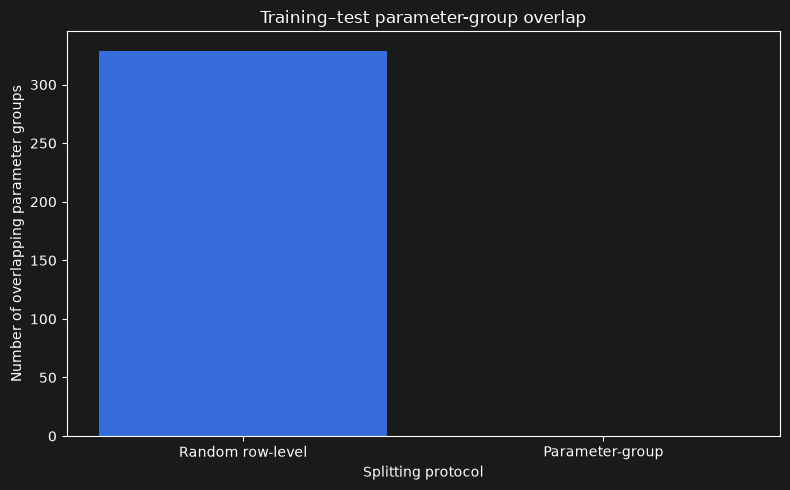

In [82]:
plt.figure(figsize=(8, 5))

plt.bar(
    overlap_comparison["protocol"],
    overlap_comparison["overlapping_groups"],
)

plt.xlabel("Splitting protocol")
plt.ylabel("Number of overlapping parameter groups")
plt.title(
    "Training–test parameter-group overlap"
)
plt.tight_layout()
plt.show()

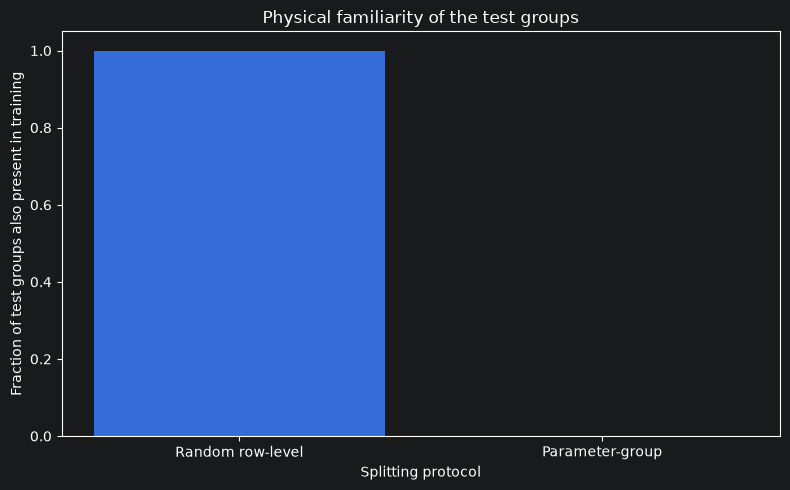

In [83]:
plt.figure(figsize=(8, 5))

plt.bar(
    overlap_comparison["protocol"],
    overlap_comparison[
        "test_groups_also_in_training_fraction"
    ],
)

plt.xlabel("Splitting protocol")
plt.ylabel(
    "Fraction of test groups also present in training"
)
plt.title(
    "Physical familiarity of the test groups"
)
plt.ylim(0.0, 1.05)
plt.tight_layout()
plt.show()

### Row-level disjointness versus group-level disjointness

Both protocols satisfy row-level disjointness:

$$
I_{\mathrm{train}}
\cap
I_{\mathrm{test}}
=
\varnothing,
$$

where $I$ denotes the set of curve indices.

Only the parameter-group split also satisfies group-level disjointness:

$$
G_{\mathrm{train}}
\cap
G_{\mathrm{test}}
=
\varnothing,
$$

where $G$ denotes the set of underlying simulation parameter groups.

The naive split is therefore not incorrect because it duplicates rows. It is problematic because it separates statistically related realizations and then treats them as independent training and test observations.

In [84]:
split_verification = pd.DataFrame(
    {
        "protocol": [
            "Random row-level",
            "Parameter-group",
        ],
        "row_overlap": [
            np.intersect1d(
                random_train_indices,
                random_test_indices,
            ).size,
            np.intersect1d(
                grouped_train_indices,
                grouped_test_indices,
            ).size,
        ],
        "group_overlap": [
            n_overlapping_groups_random,
            n_overlapping_groups_grouped,
        ],
        "all_rows_assigned": [
            (
                random_train_indices.size
                + random_test_indices.size
                == n_curves
            ),
            (
                grouped_train_indices.size
                + grouped_test_indices.size
                == n_curves
            ),
        ],
        "all_groups_assigned": [
            (
                random_train_group_set
                | random_test_group_set
                == all_parameter_group_set
            ),
            (
                grouped_train_group_set
                | grouped_test_group_set
                == all_parameter_group_set
            ),
        ],
    }
)

split_verification

,protocol,row_overlap,group_overlap,all_rows_assigned,all_groups_assigned
0,Random row-level,0,329,True,True
1,Parameter-group,0,0,True,True


In [85]:
assert split_verification[
    "row_overlap"
].eq(0).all()

assert split_verification[
    "all_rows_assigned"
].all()

assert split_verification[
    "all_groups_assigned"
].all()

assert n_overlapping_groups_random > 0
assert n_overlapping_groups_grouped == 0

### Expected random-split assignment patterns

If each realization were assigned independently to testing with probability $p=0.2$, the number of test realizations from a five-realization group would approximately follow a binomial distribution:

$$
K \sim \operatorname{Binomial}(n=5,p=0.2).
$$

The actual `train_test_split` assignment selects an exact total number of test rows without replacement, so the group counts are not perfectly independent. The binomial model is used only as an intuitive reference.

In [86]:
test_realization_counts = np.arange(
    n_realizations_per_group + 1,
    dtype=np.int64,
)

approximate_pattern_probabilities = np.array(
    [
        comb(
            n_realizations_per_group,
            int(n_test_realizations),
        )
        * group_test_size ** n_test_realizations
        * (
            1.0 - group_test_size
        ) ** (
            n_realizations_per_group
            - n_test_realizations
        )
        for n_test_realizations
        in test_realization_counts
    ],
    dtype=np.float64,
)

approximate_expected_group_counts = (
    n_parameter_groups
    * approximate_pattern_probabilities
)

In [87]:
approximate_assignment_table = pd.DataFrame(
    {
        "training_realizations": (
            n_realizations_per_group
            - test_realization_counts
        ),
        "test_realizations": test_realization_counts,
        "approximate_probability": (
            approximate_pattern_probabilities
        ),
        "approximate_expected_groups": (
            approximate_expected_group_counts
        ),
    }
)

approximate_assignment_table

,training_realizations,test_realizations,approximate_probability,approximate_expected_groups
0,5,0,0.32768,163.84
1,4,1,0.40960,204.80
2,3,2,0.20480,102.40
3,2,3,0.05120,25.60
4,1,4,0.00640,3.20
5,0,5,0.00032,0.16


### Interpretation of group-overlap verification

The two splitting protocols are both valid partitions of the curve rows, but they represent different scientific experiments.

Under the naive row-level split:

* no exact histogram is duplicated across training and testing;
* many parameter groups are represented in both subsets;
* nearly every test group is likely to have related realizations in training;
* the test score primarily measures prediction of new noise realizations from
  familiar expected decay curves.

Under the parameter-group split:

* no exact histogram is duplicated across training and testing;
* the parameter-group intersection is empty;
* all realizations from one expected decay remain together;
* every test curve comes from a parameter combination absent from training.

The parameter-group split therefore provides the more defensible estimate of interpolation performance for unfamiliar parameter combinations within the same simulated physical ranges.

This does not imply that the random-split result is useless. It answers a narrower question about prediction under repeated sampling of familiar simulation conditions. The problem arises only when that score is interpreted as evidence of broader generalization.

The next section trains identical regression models under both protocols. Any difference in performance can then be attributed to the splitting strategy rather than to different model definitions or different numbers of training and test curves.

## 6. Model training under both protocols

The random and parameter-group splits contain the same numbers of training and test curves, and both use the same normalized histogram features.

The only intended difference is the independence of the underlying simulation parameter groups:

* under the random row-level split, many test groups also appear in training;
* under the parameter-group split, all test groups are absent from training.

To isolate the effect of this difference, identical regression models and hyperparameters will be used under both protocols.

Four baselines are considered:

1. a mean-prediction baseline;
2. Ridge regression;
3. Random Forest regression;
4. Gradient Boosting regression.

The mean baseline does not use the histogram features. It predicts the mean training lifetime for every test curve. The remaining models learn a mapping from the normalized histogram bins to the fluorescence lifetime.

### Why identical models must be used

The experimental logic is:

```
random protocol:
model definition + random training data → random-protocol predictions

grouped protocol:
same model definition + grouped training data → grouped-protocol predictions
```

There should be no change, for example, of Ridge(`alpha=1.0`) for one split and Ridge(`alpha=0.1`) for another; the number of trees; the random state; feature normalization; training-set size. Otherwise, a performance difference could be caused by the model configuration rather than the split.

Model performance will be compared in the next section. The purpose of the present section is to define, fit, and verify the models and their predictions.

### Model definitions

The model configurations are defined once and treated as reusable templates.

Before training under each protocol, `sklearn.base.clone` creates a fresh, unfitted estimator with the same hyperparameters. This prevents the fitted state from one protocol from being reused accidentally in the other protocol.

In [88]:
model_random_state = 42

model_templates = {
    "Ridge": Ridge(
        alpha=1.0,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=model_random_state,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=model_random_state,
    ),
}

In [89]:
for model_name, model_template in model_templates.items():
    print(f"{model_name}:")
    print(model_template)
    print()

Ridge:
Ridge()

Random Forest:
RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

Gradient Boosting:
GradientBoostingRegressor(random_state=42)



### Mean-prediction baseline

The mean baseline predicts the average lifetime of the relevant training set for every test observation.

Although this model is intentionally simple, it provides an essential reference. A learned regression model is useful only if it performs meaningfully better than predicting one constant value for all curves.

In [90]:
def predict_training_mean(
    y_train: np.ndarray,
    n_predictions: int,
) -> np.ndarray:
    """Predict the mean training target for every requested sample."""
    if y_train.ndim != 1:
        raise ValueError("y_train must be one-dimensional.")

    if y_train.size == 0:
        raise ValueError("y_train must not be empty.")

    if n_predictions < 0:
        raise ValueError("n_predictions must be non-negative.")

    training_mean = float(np.mean(y_train))

    return np.full(
        shape=n_predictions,
        fill_value=training_mean,
        dtype=np.float64,
    )

In [92]:
mean_prediction_random = predict_training_mean(
    y_train=y_train_random,
    n_predictions=y_test_random.size,
)

mean_prediction_grouped = predict_training_mean(
    y_train=y_train_grouped,
    n_predictions=y_test_grouped.size,
)

mean_prediction_random.shape
# (500,)

mean_prediction_grouped.shape
# (500,)

(500,)

In [93]:
print(
    "Random-split training mean lifetime:",
    f"{y_train_random.mean():.4f} ns",
)

print(
    "Grouped-split training mean lifetime:",
    f"{y_train_grouped.mean():.4f} ns",
)

print(
    "First random-split baseline prediction:",
    f"{mean_prediction_random[0]:.4f} ns",
)

print(
    "First grouped-split baseline prediction:",
    f"{mean_prediction_grouped[0]:.4f} ns",
)

Random-split training mean lifetime: 2.7400 ns
Grouped-split training mean lifetime: 2.7375 ns
First random-split baseline prediction: 2.7400 ns
First grouped-split baseline prediction: 2.7375 ns


In [94]:
assert np.allclose(
    mean_prediction_random,
    y_train_random.mean(),
)

assert np.allclose(
    mean_prediction_grouped,
    y_train_grouped.mean(),
)

### Reusable training procedure

The same training function will be applied to both evaluation protocols.

For each model template, the function:

1. creates a fresh estimator using `clone`;
2. fits the estimator using only the supplied training subset;
3. predicts lifetimes for the supplied test subset;
4. stores the fitted model and prediction array.

Using one shared function reduces duplicated code and helps ensure that the random and grouped experiments follow identical training procedures.

In [95]:
def fit_and_predict_models(
    model_templates: dict[str, object],
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
) -> tuple[
    dict[str, object],
    dict[str, np.ndarray],
]:
    """Fit fresh model clones and predict the test targets."""
    if X_train.ndim != 2:
        raise ValueError("X_train must be two-dimensional.")

    if X_test.ndim != 2:
        raise ValueError("X_test must be two-dimensional.")

    if y_train.ndim != 1:
        raise ValueError("y_train must be one-dimensional.")

    if X_train.shape[0] != y_train.shape[0]:
        raise ValueError(
            "X_train and y_train must contain the same "
            "number of samples."
        )

    if X_train.shape[1] != X_test.shape[1]:
        raise ValueError(
            "X_train and X_test must contain the same "
            "number of features."
        )

    fitted_models: dict[str, object] = {}
    predictions: dict[str, np.ndarray] = {}

    for model_name, model_template in model_templates.items():
        model = clone(model_template)

        model.fit(
            X_train,
            y_train,
        )

        model_predictions = model.predict(X_test)

        fitted_models[model_name] = model
        predictions[model_name] = np.asarray(
            model_predictions,
            dtype=np.float64,
        )

    return fitted_models, predictions

In [96]:
(
    fitted_models_random,
    predictions_random,
) = fit_and_predict_models(
    model_templates=model_templates,
    X_train=X_train_random,
    y_train=y_train_random,
    X_test=X_test_random,
)

In [97]:
predictions_random = {
    "Mean baseline": mean_prediction_random,
    **predictions_random,
}

In [98]:
(
    fitted_models_grouped,
    predictions_grouped,
) = fit_and_predict_models(
    model_templates=model_templates,
    X_train=X_train_grouped,
    y_train=y_train_grouped,
    X_test=X_test_grouped,
)

In [99]:
predictions_grouped = {
    "Mean baseline": mean_prediction_grouped,
    **predictions_grouped,
}

In [100]:
expected_model_names = [
    "Mean baseline",
    "Ridge",
    "Random Forest",
    "Gradient Boosting",
]

assert list(predictions_random.keys()) == expected_model_names
assert list(predictions_grouped.keys()) == expected_model_names

assert list(fitted_models_random.keys()) == expected_model_names[1:]
assert list(fitted_models_grouped.keys()) == expected_model_names[1:]

In [101]:
for model_name in expected_model_names:
    assert predictions_random[
        model_name
    ].shape == y_test_random.shape

    assert predictions_grouped[
        model_name
    ].shape == y_test_grouped.shape

In [102]:
for model_name in expected_model_names:
    assert np.all(
        np.isfinite(
            predictions_random[model_name]
        )
    )

    assert np.all(
        np.isfinite(
            predictions_grouped[model_name]
        )
    )

In [103]:
for model_name in expected_model_names:
    assert predictions_random[model_name].ndim == 1
    assert predictions_grouped[model_name].ndim == 1

In [104]:
for model_name in model_templates:
    assert (
        fitted_models_random[model_name]
        is not fitted_models_grouped[model_name]
    )

    assert (
        fitted_models_random[model_name]
        is not model_templates[model_name]
    )

    assert (
        fitted_models_grouped[model_name]
        is not model_templates[model_name]
    )

In [105]:
assert not hasattr(
    model_templates["Ridge"],
    "coef_",
)

assert hasattr(
    fitted_models_random["Ridge"],
    "coef_",
)

assert hasattr(
    fitted_models_grouped["Ridge"],
    "coef_",
)

### Prediction sanity checks

Before calculating formal error metrics, the prediction distributions are inspected for obvious numerical problems.

The models are not explicitly constrained to predict lifetimes within the simulation interval. In particular, a linear model such as Ridge may theoretically produce values below or above the training range.

Such predictions should not be clipped automatically. Clipping would change the model output and could artificially improve evaluation metrics. Instead, the unmodified prediction ranges are reported.

In [106]:
prediction_range_rows = []

for protocol_name, predictions in [
    ("Random row-level", predictions_random),
    ("Parameter-group", predictions_grouped),
]:
    for model_name, model_predictions in predictions.items():
        prediction_range_rows.append(
            {
                "protocol": protocol_name,
                "model": model_name,
                "minimum_prediction_ns": (
                    model_predictions.min()
                ),
                "maximum_prediction_ns": (
                    model_predictions.max()
                ),
                "mean_prediction_ns": (
                    model_predictions.mean()
                ),
                "standard_deviation_ns": (
                    model_predictions.std()
                ),
            }
        )

prediction_range_table = pd.DataFrame(
    prediction_range_rows
)

prediction_range_table

,protocol,model,minimum_prediction_ns,maximum_prediction_ns,mean_prediction_ns,standard_deviation_ns
0,Random row-level,Mean baseline,2.740038,2.740038,2.740038,4.440892e-16
1,Random row-level,Ridge,0.182091,3.726648,2.690410,9.472299e-01
2,Random row-level,Random Forest,0.536629,4.941512,2.695563,1.311865e+00
3,Random row-level,Gradient Boosting,0.550201,4.959194,2.691844,1.312469e+00
4,Parameter-group,Mean baseline,2.737453,2.737453,2.737453,4.440892e-16
5,Parameter-group,Ridge,0.192461,3.720994,2.646775,1.025129e+00
6,Parameter-group,Random Forest,0.543937,4.935186,2.706110,1.360880e+00
7,Parameter-group,Gradient Boosting,0.552021,4.951547,2.706065,1.360687e+00


In [107]:
prediction_bound_rows = []

for protocol_name, predictions in [
    ("Random row-level", predictions_random),
    ("Parameter-group", predictions_grouped),
]:
    for model_name, model_predictions in predictions.items():
        below_range = (
            model_predictions
            < lifetime_range_ns[0]
        )

        above_range = (
            model_predictions
            > lifetime_range_ns[1]
        )

        prediction_bound_rows.append(
            {
                "protocol": protocol_name,
                "model": model_name,
                "predictions_below_range": int(
                    below_range.sum()
                ),
                "predictions_above_range": int(
                    above_range.sum()
                ),
                "predictions_outside_range": int(
                    (below_range | above_range).sum()
                ),
            }
        )

prediction_bound_table = pd.DataFrame(
    prediction_bound_rows
)

prediction_bound_table

,protocol,model,predictions_below_range,predictions_above_range,predictions_outside_range
0,Random row-level,Mean baseline,0,0,0
1,Random row-level,Ridge,10,0,10
2,Random row-level,Random Forest,0,0,0
3,Random row-level,Gradient Boosting,0,0,0
4,Parameter-group,Mean baseline,0,0,0
5,Parameter-group,Ridge,30,0,30
6,Parameter-group,Random Forest,0,0,0
7,Parameter-group,Gradient Boosting,0,0,0


In [108]:
random_prediction_preview = pd.DataFrame(
    {
        "true_lifetime_ns": y_test_random[:10],
        **{
            model_name: model_predictions[:10]
            for model_name, model_predictions
            in predictions_random.items()
        },
    }
)

random_prediction_preview

,true_lifetime_ns,Mean baseline,Ridge,Random Forest,Gradient Boosting
0,0.957524,2.740038,1.215320,0.954974,0.964666
1,3.482889,2.740038,3.409253,3.647197,3.567381
2,1.398990,2.740038,1.913549,1.385147,1.367904
3,2.563523,2.740038,2.952248,2.564422,2.533373
4,3.378035,2.740038,3.342422,3.423265,3.429986
5,2.060914,2.740038,2.626853,2.012418,2.046702
6,2.207588,2.740038,2.726922,2.190966,2.178397
7,2.339524,2.740038,2.814182,2.337446,2.353185
8,4.828539,2.740038,3.694939,4.825238,4.853128
9,2.441382,2.740038,2.892070,2.433348,2.453234


In [109]:
grouped_prediction_preview = pd.DataFrame(
    {
        "true_lifetime_ns": y_test_grouped[:10],
        **{
            model_name: model_predictions[:10]
            for model_name, model_predictions
            in predictions_grouped.items()
        },
    }
)

grouped_prediction_preview

,true_lifetime_ns,Mean baseline,Ridge,Random Forest,Gradient Boosting
0,3.982802,2.737453,3.506524,4.007118,3.968467
1,3.982802,2.737453,3.504219,3.973892,3.956532
2,3.982802,2.737453,3.500298,3.972081,3.963290
3,3.982802,2.737453,3.505470,3.993275,3.960896
4,3.982802,2.737453,3.496909,3.961446,3.986231
5,4.363691,2.737453,3.594879,4.317351,4.395792
6,4.363691,2.737453,3.591664,4.337030,4.422780
7,4.363691,2.737453,3.591044,4.395947,4.393145
8,4.363691,2.737453,3.598599,4.359866,4.395425
9,4.363691,2.737453,3.594039,4.343696,4.259112


### Preliminary prediction visualization

The following scatter plots provide a qualitative check of the predictions. They are not a substitute for numerical metrics.

A perfect regressor would place every point on the diagonal line

$$
\hat{\tau}=\tau.
$$

Systematic deviations from the diagonal may reveal bias, compression of the prediction range, or poor performance near the lifetime boundaries.

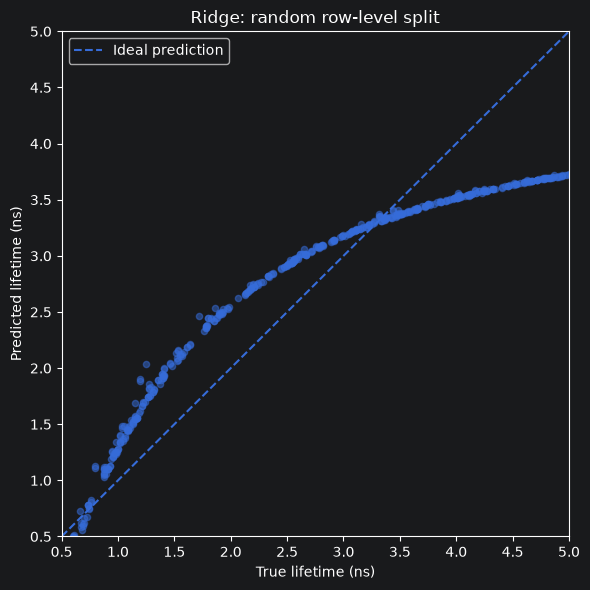

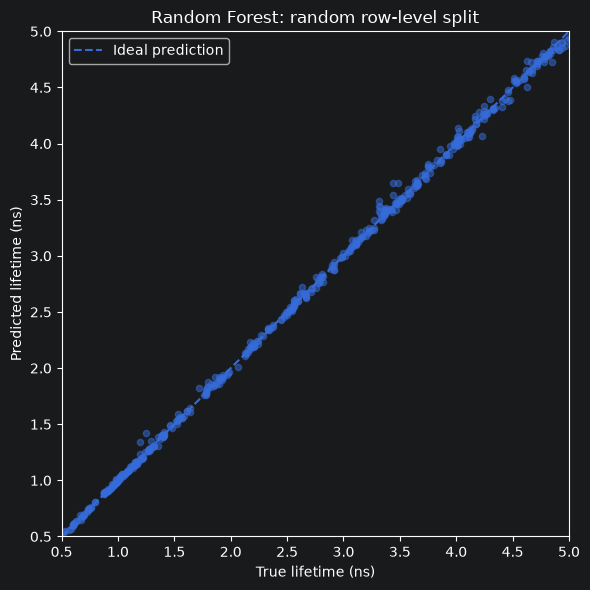

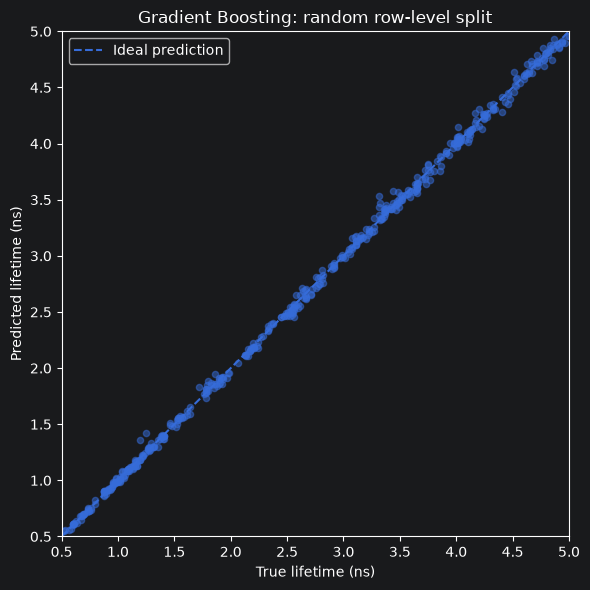

In [110]:
for model_name in [
    "Ridge",
    "Random Forest",
    "Gradient Boosting",
]:
    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test_random,
        predictions_random[model_name],
        alpha=0.5,
        s=20,
    )

    plt.plot(
        lifetime_range_ns,
        lifetime_range_ns,
        linestyle="--",
        label="Ideal prediction",
    )

    plt.xlabel("True lifetime (ns)")
    plt.ylabel("Predicted lifetime (ns)")
    plt.title(
        f"{model_name}: random row-level split"
    )
    plt.xlim(lifetime_range_ns)
    plt.ylim(lifetime_range_ns)
    plt.legend()
    plt.tight_layout()
    plt.show()

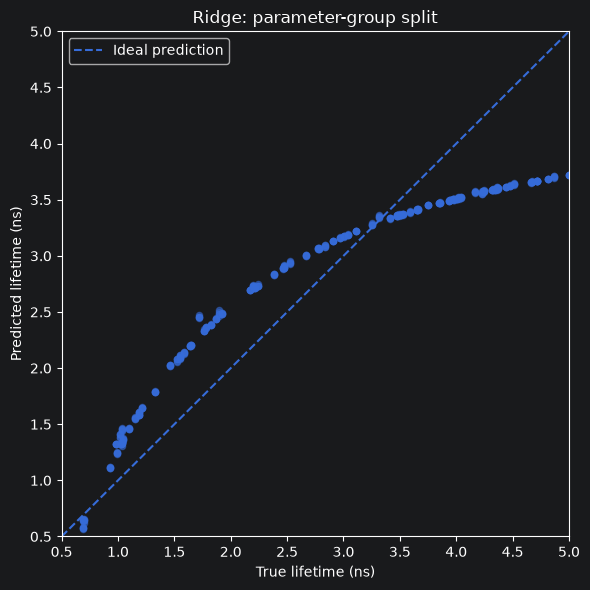

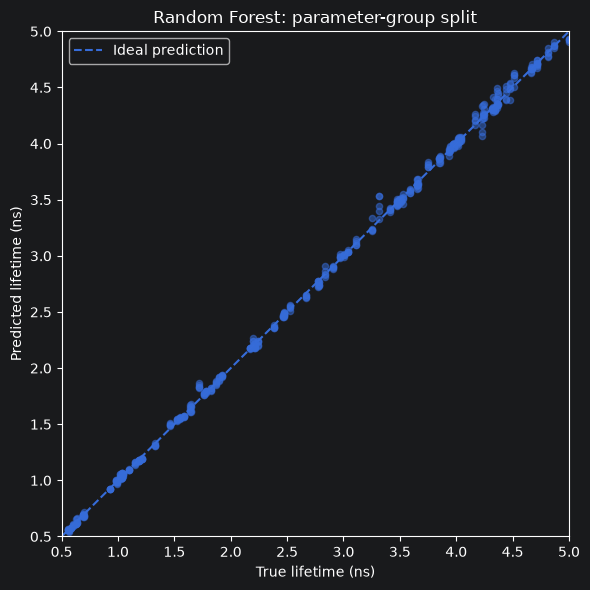

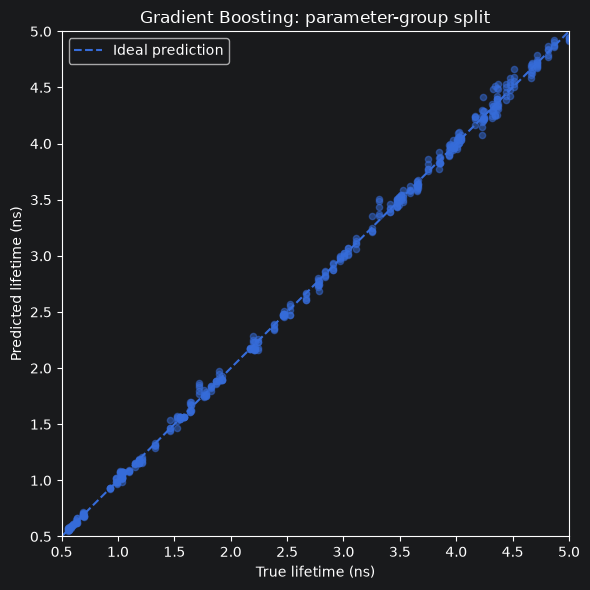

In [111]:
for model_name in [
    "Ridge",
    "Random Forest",
    "Gradient Boosting",
]:
    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test_grouped,
        predictions_grouped[model_name],
        alpha=0.5,
        s=20,
    )

    plt.plot(
        lifetime_range_ns,
        lifetime_range_ns,
        linestyle="--",
        label="Ideal prediction",
    )

    plt.xlabel("True lifetime (ns)")
    plt.ylabel("Predicted lifetime (ns)")
    plt.title(
        f"{model_name}: parameter-group split"
    )
    plt.xlim(lifetime_range_ns)
    plt.ylim(lifetime_range_ns)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Interpretation of model training

Identical model templates have now been trained under both splitting protocols.

For each protocol:

* the mean baseline uses only the corresponding training-target mean;
* Ridge learns a regularized linear relationship between normalized histogram bins and lifetime;
* Random Forest learns a nonlinear ensemble of regression trees;
* Gradient Boosting sequentially builds trees that correct previous residual errors;
* every model generates one finite lifetime prediction per test curve.

Fresh estimator clones were used for each protocol, so the fitted state from one experiment cannot influence the other.

The two prediction collections differ only because the models were trained and tested using different row assignments:

```text
predictions_random
predictions_grouped
```

The random protocol allows physically familiar parameter groups across the training–test boundary, whereas the grouped protocol evaluates completely held-out parameter combinations.

The next section calculates identical error metrics for both prediction collections and determines how strongly the apparent model performance depends on the splitting strategy.